In [258]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt

import darling
import disell

In [ ]:

base = Path(
    "~/Documents/Data/4dcells/111_june/"
    "111_cells_2_6-3pct_mosalayers_2x"
).expanduser()

print(base)
print(base.exists())

out = base / "disell_output"
out.mkdir(parents=True, exist_ok=True)

print("Output folder:", out)

/home/adam/Documents/Data/4dcells/111_june/111_cells_2_6-2pct_mosalayers_2x
True
Output folder: /home/adam/Documents/Data/4dcells/111_june/111_cells_2_6-2pct_mosalayers_2x/disell_output


In [260]:
def get_layer_number(path):
    return int(re.search(r"layer_(\d+)_", path.name).group(1))


layer_dirs = sorted(
    [p for p in base.iterdir() if p.is_dir() and p.name.startswith("layer_")],
    key=get_layer_number,
)

volume = np.stack([np.load(p / "mean.npy") for p in layer_dirs], axis=0)

motors = np.load(layer_dirs[0] /  "motors.npy")

print("layers:", [p.name for p in layer_dirs])
print("volume:", volume.shape)

volume = volume[:, 150:-150, 0:-200, :]
print("volume:", volume.shape)

layers: ['layer_1_1', 'layer_2_1', 'layer_3_1', 'layer_4_1', 'layer_5_1', 'layer_6_1', 'layer_7_1', 'layer_8_1', 'layer_9_1', 'layer_10_1', 'layer_11_1']
volume: (11, 925, 925, 2)
volume: (11, 625, 725, 2)


(np.float64(-0.5), np.float64(724.5), np.float64(624.5), np.float64(-0.5))

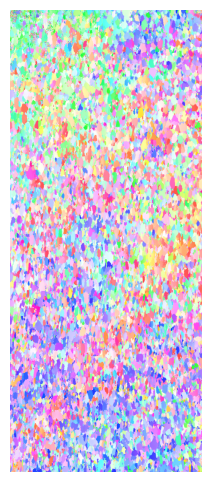

In [261]:
rgb_volume = []

for z in range(volume.shape[0]):
    rgb, _, _ = darling.transforms.rgb(
        volume[z],
        norm="dynamic",
        coordinates=motors,
    )
    rgb_volume.append(rgb)

rgb_volume = np.stack(rgb_volume, axis=0)

plt.figure(figsize=(6, 6))
plt.imshow(rgb_volume[z], aspect=2.8)
plt.axis("off")


In [262]:
transforms = disell.register(
    volume,
    registration_channel=0,
    verbose=True,
)

registered = disell.apply_transforms(
    volume,
    transforms,
    pad_value=np.nan,
)

print("registered:", registered.shape)

[0] Shift: [ 3. -1.]
[1] Shift: [2. 0.]
[2] Shift: [2. 0.]
[3] Shift: [1. 0.]
[4] Shift: [0. 0.]
[6] Shift: [0. 0.]
[7] Shift: [-1.  0.]
[8] Shift: [-2.  0.]
[9] Shift: [-2.  0.]
[10] Shift: [-3.  0.]
registered: (11, 625, 725, 2)


(np.float64(-0.5), np.float64(724.5), np.float64(624.5), np.float64(-0.5))

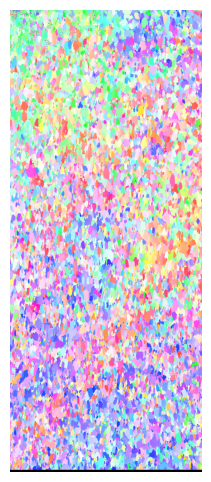

In [263]:
rgb_volume = []

for z in range(registered.shape[0]):
    rgb, colorkey, colorgrid = darling.transforms.rgb(
        registered[z],
        norm="dynamic",
        coordinates=motors,
    )
    rgb_volume.append(rgb)

rgb_volume2 = np.stack(rgb_volume, axis=0)

plt.figure(figsize=(6, 6))
plt.imshow(rgb_volume[z], aspect=2.8)
plt.axis("off")

In [264]:
mask = np.all(np.isfinite(registered), axis=-1)

seg_input = registered.copy()

for c in range(seg_input.shape[-1]):
    vals = seg_input[..., c][mask]
    lo, hi = np.nanpercentile(vals, [1, 99])
    seg_input[..., c] = (seg_input[..., c] - lo) / (hi - lo)

seg_input[~np.isfinite(seg_input)] = 0

In [265]:
footprint = np.ones((3, 3, 3), dtype=bool)

footprint[1, :, :] = True

footprint[0, :, 1] = True
footprint[0, 1, :] = True
footprint[2, 1, :] = True
footprint[2, :, 1] = True


In [266]:
import numpy as np
from skimage.segmentation import relabel_sequential


marker_result, sizes_initial = disell.flood_fill_dfxm_two_stage(
    seg_input,
    footprint=footprint,
    local_misorientation_threshold=0.015,
    global_threshold=0.3,
    footprint_tolerance=0.85,
    mask=mask,
    max_iterations=50_000,
    min_grain_size=4,
    recycle_small_grains=False,
    stagnation_tolerance=1000,
)

markers = marker_result["segmentation"]
mask_bool = mask.astype(bool)


kam_volume = disell.kam(seg_input, ndim=3, size=(3, 3, 3))
kam_volume = np.asarray(kam_volume)

if kam_volume.shape == markers.shape + (1,):
    kam_volume = kam_volume[..., 0]

assert kam_volume.shape == markers.shape

watershed_feature = np.asarray(kam_volume, dtype=float).copy()
finite_inside = np.isfinite(watershed_feature[mask_bool])
if np.any(finite_inside):
    fill_value = np.nanmax(watershed_feature[mask_bool][finite_inside])
else:
    fill_value = 1.0
watershed_feature[~np.isfinite(watershed_feature)] = fill_value


final_labels = disell.region_grow_watershed(
    seg=markers,
    mask=mask_bool,
    feature=watershed_feature,
    connectivity=1,
)
final_labels = final_labels.astype(np.int32, copy=False)

# Make labels contiguous for easier downstream analysis.
final_labels, _fw, _inv = relabel_sequential(final_labels)
final_labels = np.asarray(final_labels)

print("markers shape:", markers.shape)
print("number of marker labels:", int(markers.max()))
print("number of final labels:", int(final_labels.max()))

markers shape: (11, 625, 725)
number of marker labels: 9688
number of final labels: 9688


In [267]:
# ---- KAM / feature diagnostics ----
print("KAM volume shape:", kam_volume.shape)

finite_fraction = (
    np.count_nonzero(np.isfinite(kam_volume[mask_bool]))
    / np.count_nonzero(mask_bool)
)
print(f"KAM finite fraction inside mask: {finite_fraction:.3f}")
print(
    "KAM min/max inside mask:",
    np.nanmin(kam_volume[mask_bool]),
    np.nanmax(kam_volume[mask_bool]),
)

# ---- shape / content sanity checks ----
assert markers.shape == mask_bool.shape
assert kam_volume.shape == mask_bool.shape
assert watershed_feature.shape == mask_bool.shape
assert final_labels.shape == mask_bool.shape
assert np.count_nonzero(markers > 0) > 0

# ---- mask-aware coverage (divide by valid mask, not the full rectangular array) ----
marker_fraction = (
    np.count_nonzero((markers > 0) & mask_bool)
    / np.count_nonzero(mask_bool)
)
final_fraction = (
    np.count_nonzero((final_labels > 0) & mask_bool)
    / np.count_nonzero(mask_bool)
)

print("markers shape:", markers.shape)
print("number of marker labels:", int(markers.max()))
print("number of final labels:", int(final_labels.max()))
print(f"Marker coverage inside mask: {100 * marker_fraction:.1f}%")
print(f"Final coverage inside mask: {100 * final_fraction:.1f}%")

# The marker coverage may be ~50% (that is fine). The watershed-refined final
# coverage should be ~100% inside the mask. If not, report what went wrong.
if final_fraction < 0.99:
    print("\n[WARNING] Final coverage is below 99% inside the mask:")
    print("  number of marker labels:", int(markers.max()))
    print(f"  marker coverage inside mask: {100 * marker_fraction:.1f}%")
    print(f"  final coverage inside mask: {100 * final_fraction:.1f}%")
    print(
        "  NaNs in KAM/feature inside mask:",
        int(np.count_nonzero(~np.isfinite(kam_volume[mask_bool]))),
    )
    print("  True voxels in mask:", int(np.count_nonzero(mask_bool)))

# Convenience alias: downstream cells operate on the FINAL segmentation.
labels = final_labels

KAM volume shape: (11, 625, 725)
KAM finite fraction inside mask: 1.000
KAM min/max inside mask: 0.0 1.1794801766079064
markers shape: (11, 625, 725)
number of marker labels: 9688
number of final labels: 9688
Marker coverage inside mask: 35.0%
Final coverage inside mask: 100.0%


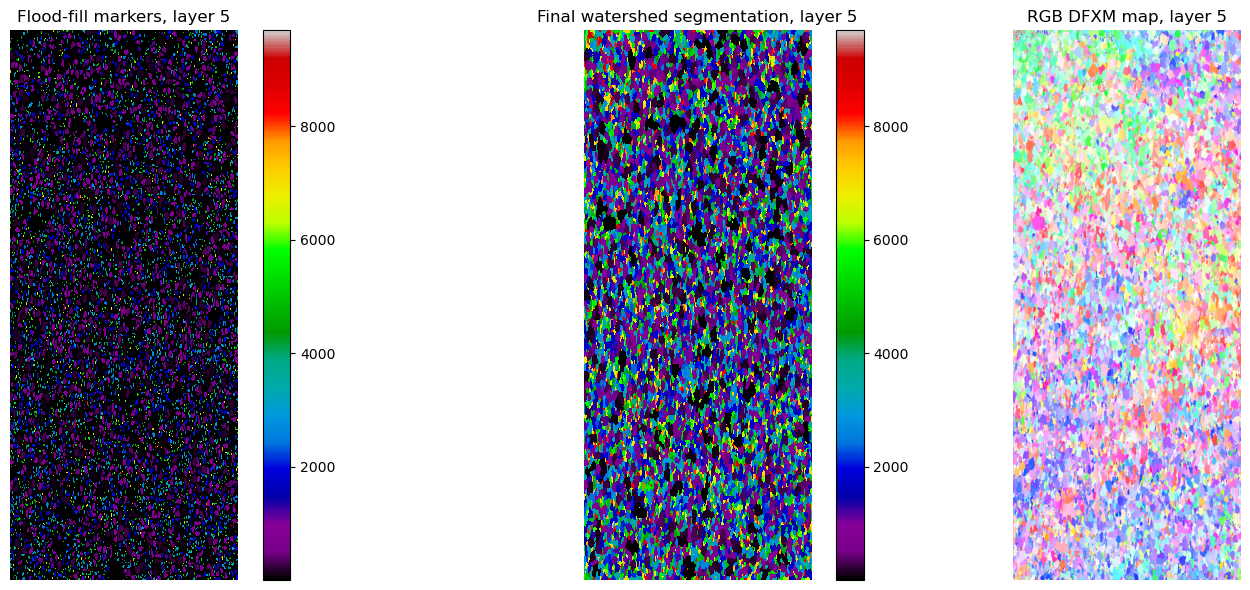

In [268]:
import matplotlib as mpl
import matplotlib.pyplot as plt

z = final_labels.shape[0] // 2

# Choose zoom region in (y, x)
y0, y1 = 0, -1
x0, x1 = 0, -1

markers_crop = markers[z]
final_crop = final_labels[z]
rgb_crop = rgb_volume[z]

# Copy colormap and set label 0 to black
cmap = mpl.colormaps["nipy_spectral"].copy()
cmap.set_under("black")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im0 = axes[0].imshow(
    markers_crop,
    cmap=cmap,
    interpolation="nearest",
    aspect=2.8,
    vmin=0.5,   # values below this, i.e. label 0, use set_under colour
)
axes[0].set_title(f"Flood-fill markers, layer {z}")
axes[0].axis("off")

im1 = axes[1].imshow(
    final_crop,
    cmap=cmap,
    interpolation="nearest",
    aspect=2.8,
    vmin=0.5,
)
axes[1].set_title(f"Final watershed segmentation, layer {z}")
axes[1].axis("off")

axes[2].imshow(rgb_crop, aspect=2.8)
axes[2].set_title(f"RGB DFXM map, layer {z}")
axes[2].axis("off")

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

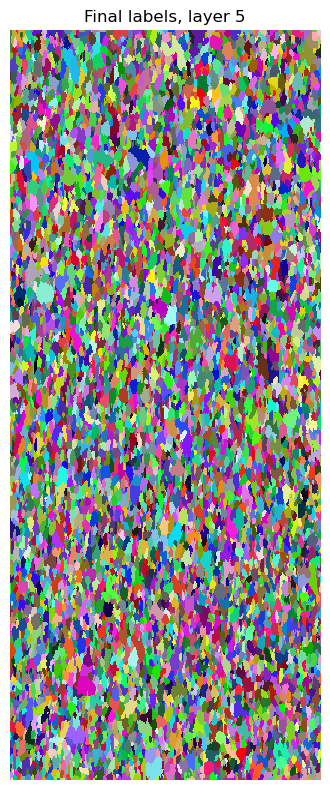

In [269]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

def random_label_cmap(n_labels, seed=0):
    rng = np.random.default_rng(seed)
    colors = rng.random((n_labels + 1, 4))
    colors[:, 3] = 1.0
    colors[0] = [0, 0, 0, 1]  # label 0 = black
    return mpl.colors.ListedColormap(colors)

z = final_labels.shape[0] // 2

cmap_labels = random_label_cmap(int(final_labels.max()), seed=0)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(
    final_labels[z],
    cmap=cmap_labels,
    interpolation="nearest",
    aspect=2.8,
    vmin=0,
    vmax=final_labels.max(),
)
ax.set_title(f"Final labels, layer {z}")
ax.axis("off")
plt.tight_layout()
plt.show()

In [270]:
rgb.shape

(625, 725, 3)

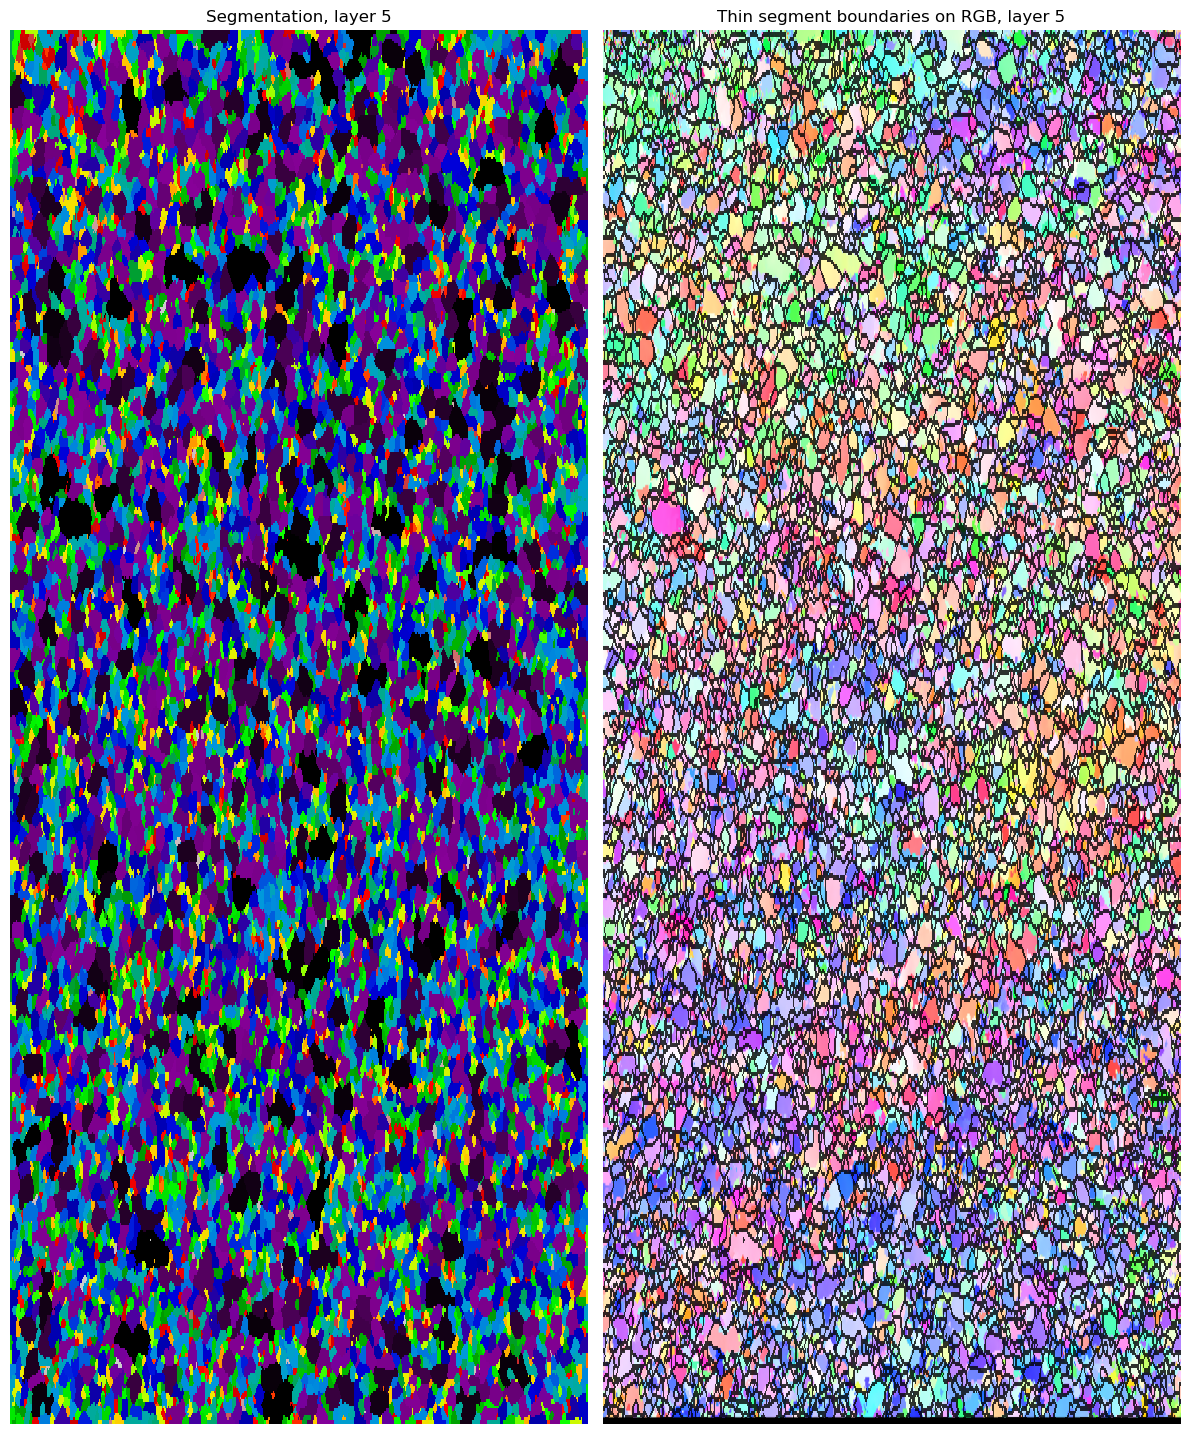

In [271]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries

z = labels.shape[0] // 2

y0, y1 = 0, -1
x0, x1 = 0, -1



# Thin 1-pixel boundaries
boundaries = find_boundaries(
    labels[z],
    mode="inner",
    background=0,
)

# Only keep boundaries inside segmented regions
boundaries = boundaries & (labels[z] > 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 15))

axes[0].imshow(labels[z], cmap="nipy_spectral", interpolation="nearest", aspect=2.8)
axes[0].set_title(f"Segmentation, layer {z}")
axes[0].axis("off")

axes[1].imshow(rgb, aspect=2.8)

boundary_overlay = np.zeros((*boundaries.shape, 4))
boundary_overlay[boundaries] = [0, 0, 0, 0.8]  # black, slightly transparent

axes[1].imshow(boundary_overlay, interpolation="nearest", aspect=2.8)
axes[1].set_title(f"Thin segment boundaries on RGB, layer {z}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Number of segmented cells in layer 6: 8513
Median cell area: 35.0 pixels
Mean cell area: 53.2 pixels


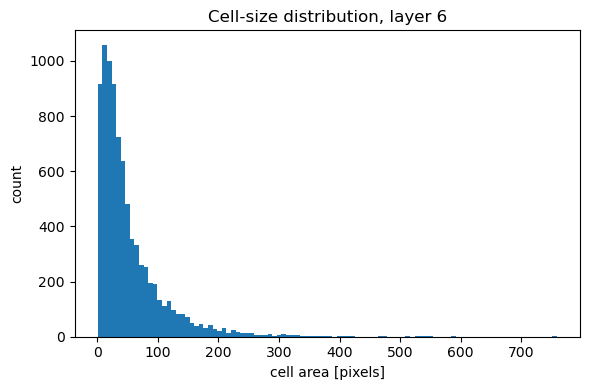

In [272]:
z = (labels.shape[0] // 2)+1

labels_z = labels[z]

# Count pixels per label
label_ids, counts = np.unique(labels_z, return_counts=True)

# Remove background label 0
valid = label_ids > 0
label_ids = label_ids[valid]
cell_sizes_px = counts[valid]

print(f"Number of segmented cells in layer {z}: {len(cell_sizes_px)}")
print(f"Median cell area: {np.median(cell_sizes_px):.1f} pixels")
print(f"Mean cell area: {np.mean(cell_sizes_px):.1f} pixels")

plt.figure(figsize=(6, 4))
plt.hist(cell_sizes_px, bins=100)
plt.xlabel("cell area [pixels]")
plt.ylabel("count")
plt.title(f"Cell-size distribution, layer {z}")
plt.tight_layout()
plt.show()

Number of segmented 3D cells: 9688
Min cell volume: 4 voxels
Median cell volume: 310.0 voxels
Mean cell volume: 513.2 voxels
Max cell volume: 8485 voxels


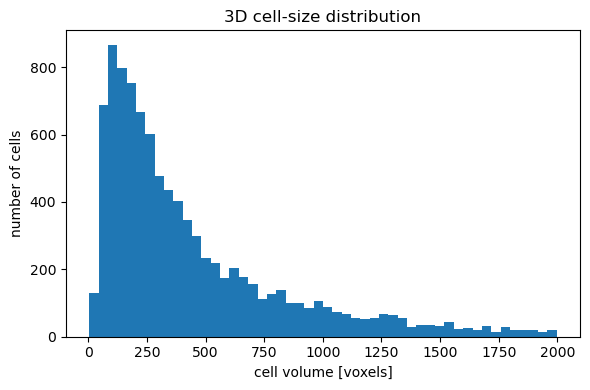

In [273]:
label_ids, counts = np.unique(labels, return_counts=True)

# Remove background / unsegmented label
valid = label_ids > 0
label_ids = label_ids[valid]
cell_sizes_vox = counts[valid]

print(f"Number of segmented 3D cells: {len(cell_sizes_vox)}")
print(f"Min cell volume: {cell_sizes_vox.min()} voxels")
print(f"Median cell volume: {np.median(cell_sizes_vox):.1f} voxels")
print(f"Mean cell volume: {np.mean(cell_sizes_vox):.1f} voxels")
print(f"Max cell volume: {cell_sizes_vox.max()} voxels")

upper = np.percentile(cell_sizes_vox, 90)

plt.figure(figsize=(6, 4))
plt.hist(cell_sizes_vox[cell_sizes_vox <= 2000], bins=50)
plt.xlabel("cell volume [voxels]")
plt.ylabel("number of cells")
plt.title("3D cell-size distribution")
plt.tight_layout()
plt.show()

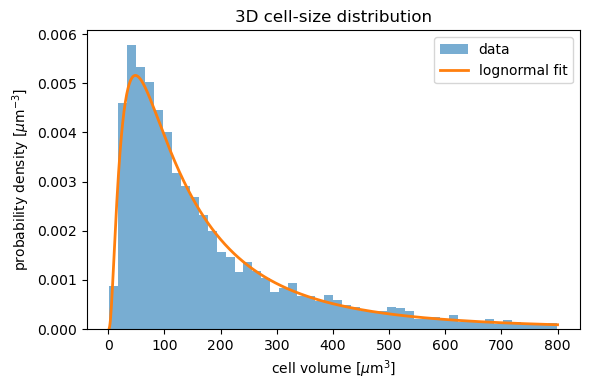

In [274]:
# Voxel size in micrometres
dx = 0.4  # µm, x pixel size = 400 nm
dy = 1.0  # µm
dz = 1.0  # µm

voxel_volume_um3 = dx * dy * dz

# Convert cell volumes from voxels to physical volume
cell_sizes_um3 = cell_sizes_vox * voxel_volume_um3

# Plotting cutoff in physical units
upper_vox = 2000  # only for plotting
upper_um3 = upper_vox * voxel_volume_um3

# IMPORTANT:
# If sigma, loc, scale were fitted to cell_sizes_vox,
# then either refit in µm³, or transform scale/loc.
# Safest: fit directly to physical volumes.
sigma, loc, scale = lognorm.fit(cell_sizes_um3, floc=0)

x = np.linspace(cell_sizes_um3.min(), upper_um3, 1000)
pdf = lognorm.pdf(x, s=sigma, loc=loc, scale=scale)

plt.figure(figsize=(6, 4))

plt.hist(
    cell_sizes_um3[cell_sizes_um3 <= upper_um3],
    bins=50,
    density=True,
    alpha=0.6,
    label="data",
)

plt.plot(
    x,
    pdf,
    linewidth=2,
    label="lognormal fit",
)

plt.xlabel(r"cell volume [$\mu$m$^3$]")
plt.ylabel(r"probability density [$\mu$m$^{-3}$]")
plt.title("3D cell-size distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [275]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# cell_sizes_um3 already in µm³
cell_diam_um = (6.0 * cell_sizes_um3 / np.pi) ** (1.0 / 3.0)

print(f"Number of cells: {len(cell_diam_um)}")
print(f"Min equivalent diameter: {cell_diam_um.min():.2f} µm")
print(f"Median equivalent diameter: {np.median(cell_diam_um):.2f} µm")
print(f"Mean equivalent diameter: {np.mean(cell_diam_um):.2f} µm")
print(f"Max equivalent diameter: {cell_diam_um.max():.2f} µm")

Number of cells: 9688
Min equivalent diameter: 1.45 µm
Median equivalent diameter: 6.19 µm
Mean equivalent diameter: 6.59 µm
Max equivalent diameter: 18.65 µm


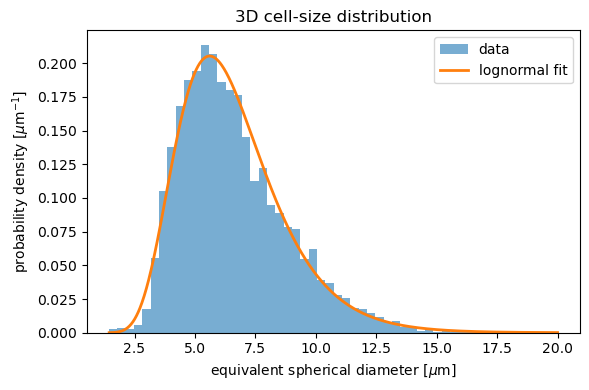

In [276]:
upper_diam = 20  # µm, only for plotting

sigma_d, loc_d, scale_d = lognorm.fit(cell_diam_um, floc=0)

x = np.linspace(cell_diam_um.min(), upper_diam, 1000)
pdf = lognorm.pdf(x, s=sigma_d, loc=loc_d, scale=scale_d)

plt.figure(figsize=(6, 4))

plt.hist(
    cell_diam_um[cell_diam_um <= upper_diam],
    bins=50,
    density=True,
    alpha=0.6,
    label="data",
)

plt.plot(
    x,
    pdf,
    linewidth=2,
    label="lognormal fit",
)

plt.xlabel(r"equivalent spherical diameter [$\mu$m]")
plt.ylabel(r"probability density [$\mu$m$^{-1}$]")
plt.title("3D cell-size distribution")
plt.legend()
plt.tight_layout()
plt.show()

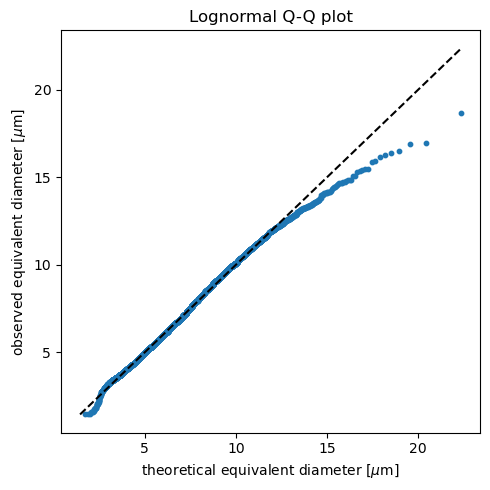

In [277]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Fit lognormal to equivalent spherical diameters
sigma_d, loc_d, scale_d = lognorm.fit(cell_diam_um, floc=0)
mu_d = np.log(scale_d)

# Sort observed diameters
observed = np.sort(cell_diam_um)

n = len(observed)
p = (np.arange(1, n + 1) - 0.5) / n

# Theoretical quantiles from fitted lognormal
theoretical = lognorm.ppf(
    p,
    s=sigma_d,
    loc=loc_d,
    scale=scale_d,
)

plt.figure(figsize=(5, 5))
plt.scatter(theoretical, observed, s=10)

lims = [
    min(theoretical.min(), observed.min()),
    max(theoretical.max(), observed.max()),
]

plt.plot(lims, lims, "k--")

plt.xlabel(r"theoretical equivalent diameter [$\mu$m]")
plt.ylabel(r"observed equivalent diameter [$\mu$m]")
plt.title("Lognormal Q-Q plot")
plt.tight_layout()
plt.show()

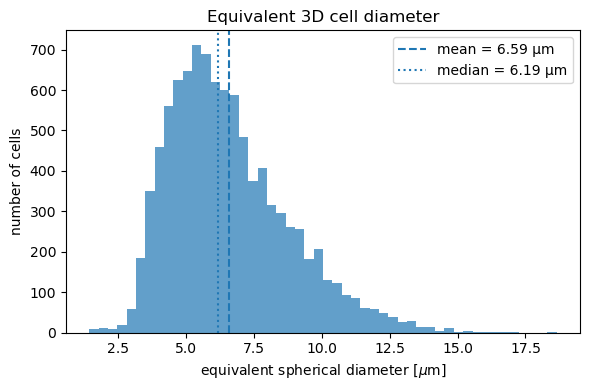

In [278]:
# 3D equivalent spherical diameter from volume in µm³
D_eq_3d_um = (6.0 * cell_sizes_um3 / np.pi) ** (1.0 / 3.0)

upper_diam = 20  # µm, only for plotting

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    D_eq_3d_um[D_eq_3d_um <= upper_diam],
    bins=50,
    alpha=0.7,
)

ax.axvline(
    np.mean(D_eq_3d_um),
    linestyle="--",
    label=f"mean = {np.mean(D_eq_3d_um):.2f} µm",
)

ax.axvline(
    np.median(D_eq_3d_um),
    linestyle=":",
    label=f"median = {np.median(D_eq_3d_um):.2f} µm",
)

ax.set_xlabel(r"equivalent spherical diameter [$\mu$m]")
ax.set_ylabel("number of cells")
ax.set_title("Equivalent 3D cell diameter")
ax.legend()
plt.tight_layout()
plt.show()

In [279]:
z = final_labels.shape[0] // 2

dx = 0.4  # µm
dy = 1.0  # µm

slice_labels = final_labels[z]

label_ids, counts_2d = np.unique(slice_labels, return_counts=True)

# Remove background
valid = label_ids > 0
label_ids_2d = label_ids[valid]
cell_areas_pix = counts_2d[valid]

# Convert pixels to µm²
pixel_area_um2 = dx * dy
cell_areas_um2 = cell_areas_pix * pixel_area_um2

# Equivalent circular diameter
D_eq_2d_um = 2.0 * np.sqrt(cell_areas_um2 / np.pi)

print(f"Number of 2D cells/intersections: {len(D_eq_2d_um)}")
print(f"Median 2D equivalent diameter: {np.median(D_eq_2d_um):.2f} µm")
print(f"Mean 2D equivalent diameter: {np.mean(D_eq_2d_um):.2f} µm")

Number of 2D cells/intersections: 8610
Median 2D equivalent diameter: 4.16 µm
Mean 2D equivalent diameter: 4.61 µm


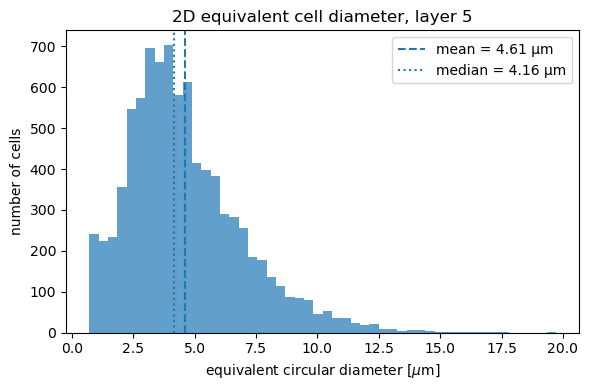

In [280]:
upper_diam = 20  # µm

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    D_eq_2d_um[D_eq_2d_um <= upper_diam],
    bins=50,
    alpha=0.7,
)

ax.axvline(
    np.mean(D_eq_2d_um),
    linestyle="--",
    label=f"mean = {np.mean(D_eq_2d_um):.2f} µm",
)

ax.axvline(
    np.median(D_eq_2d_um),
    linestyle=":",
    label=f"median = {np.median(D_eq_2d_um):.2f} µm",
)

ax.set_xlabel(r"equivalent circular diameter [$\mu$m]")
ax.set_ylabel("number of cells")
ax.set_title(f"2D equivalent cell diameter, layer {z}")
ax.legend()
plt.tight_layout()
plt.show()

In [281]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

label_ids, counts = np.unique(labels, return_counts=True)

# Remove background / unsegmented label
valid = label_ids > 0
label_ids = label_ids[valid]
cell_sizes_vox = counts[valid].astype(float)

print(f"Number of segmented 3D cells: {len(cell_sizes_vox)}")
print(f"Min cell volume: {cell_sizes_vox.min():.0f} voxels")
print(f"Median cell volume: {np.median(cell_sizes_vox):.1f} voxels")
print(f"Mean cell volume: {np.mean(cell_sizes_vox):.1f} voxels")
print(f"Max cell volume: {cell_sizes_vox.max():.0f} voxels")

# Fit lognormal: shape=sigma, loc, scale=exp(mu)
sigma, loc, scale = lognorm.fit(cell_sizes_vox, floc=0)
mu = np.log(scale)

print("\nLognormal fit:")
print(f"mu    = {mu:.4f}")
print(f"sigma = {sigma:.4f}")
print(f"scale = exp(mu) = {scale:.2f} voxels")
print(f"median fit = {np.exp(mu):.2f} voxels")
print(f"mean fit   = {np.exp(mu + sigma**2 / 2):.2f} voxels")

Number of segmented 3D cells: 9688
Min cell volume: 4 voxels
Median cell volume: 310.0 voxels
Mean cell volume: 513.2 voxels
Max cell volume: 8485 voxels

Lognormal fit:
mu    = 5.7646
sigma = 0.9850
scale = exp(mu) = 318.80 voxels
median fit = 318.80 voxels
mean fit   = 517.85 voxels


In [282]:
from scipy import ndimage as ndi
import numpy as np

# Same connectivity as before:
# - full 8-connectivity in-plane
# - direct z-neighbour connectivity between layers
structure = np.zeros((3, 3, 3), dtype=bool)
structure[1, :, :] = True
structure[0, 1, 1] = True
structure[2, 1, 1] = True

labels_split = np.zeros_like(labels, dtype=np.int32)

new_label = 1
split_info = []

for old_label in np.unique(labels):
    if old_label == 0:
        continue

    old_mask = labels == old_label
    cc, n_cc = ndi.label(old_mask, structure=structure)

    if n_cc > 1:
        sizes = np.bincount(cc.ravel())[1:]
        split_info.append((old_label, n_cc, sizes))

    for component_id in range(1, n_cc + 1):
        component = cc == component_id
        labels_split[component] = new_label
        new_label += 1

print("old max label:", int(labels.max()))
print("new max label:", int(labels_split.max()))
print("labels split:", len(split_info))
print("extra components:", int(labels_split.max() - labels.max()))

coverage_before = np.count_nonzero((labels > 0) & mask_bool) / np.count_nonzero(mask_bool)
coverage_after = np.count_nonzero((labels_split > 0) & mask_bool) / np.count_nonzero(mask_bool)

print(f"coverage before: {coverage_before:.4%}")
print(f"coverage after:  {coverage_after:.4%}")

old max label: 9688
new max label: 9723
labels split: 23
extra components: 35
coverage before: 100.0000%
coverage after:  100.0000%


In [283]:
labels = labels_split

In [284]:
import pyvista as pv

In [285]:
ids, counts = np.unique(labels, return_counts=True)

# Remove background
keep = ids != 0
ids = ids[keep]
counts = counts[keep]

order = np.argsort(counts)[::-1]

for i in range(min(20, len(ids))):
    print(f"label {ids[order[i]]}: {counts[order[i]]} voxels")

label 1: 8485 voxels
label 3: 6358 voxels
label 2: 6317 voxels
label 4: 5875 voxels
label 7: 5784 voxels
label 6: 5622 voxels
label 8: 5521 voxels
label 9: 5269 voxels
label 5: 5205 voxels
label 12: 4850 voxels
label 17: 4844 voxels
label 16: 4805 voxels
label 25: 4760 voxels
label 22: 4688 voxels
label 10: 4480 voxels
label 23: 4468 voxels
label 47: 4284 voxels
label 14: 4263 voxels
label 11: 4263 voxels
label 74: 4250 voxels


In [286]:
cell_id = ids[order[180]]
print("chosen cell:", cell_id)

chosen cell: 256


In [287]:
rgb_volume = np.asarray(rgb_volume)

rgb_volume.shape

(11, 625, 725, 3)

In [288]:
cell_mask = labels == cell_id

zz, yy, xx = np.nonzero(cell_mask)

points = np.column_stack([xx, yy, zz]).astype(float)
colors = rgb_volume[cell_mask]

print("points:", points.shape)
print("colors:", colors.shape)

points: (2397, 3)
colors: (2397, 3)


/tmp/ipykernel_176548/3468620496.py:21: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


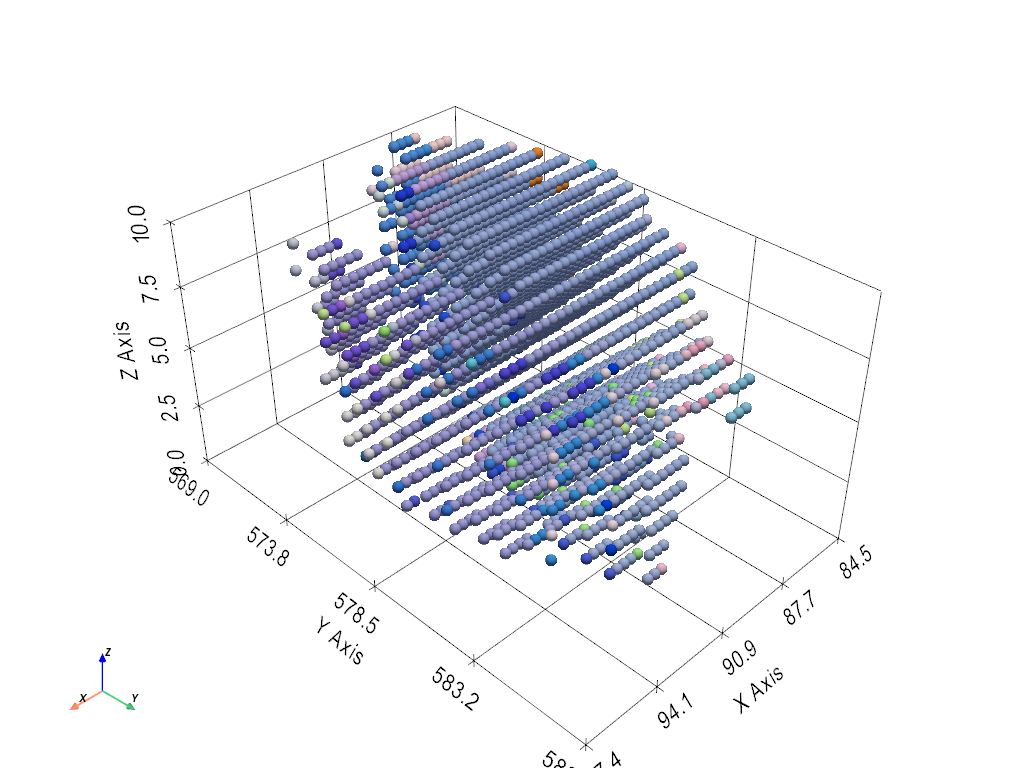

In [289]:
cloud = pv.PolyData(points)
cloud["RGB"] = (np.clip(colors, 0, 1) * 255).astype(np.uint8)


cloud_scaled = cloud.copy()

scale = np.array([0.33, 1, 1.0])  # x = 400 nm = 0.4 µm, y = 1 µm, z = 1 µm

cloud_scaled.points = cloud_scaled.points * scale

plotter = pv.Plotter()
plotter.add_points(
    cloud_scaled,
    scalars="RGB",
    rgb=True,
    point_size=12,
    render_points_as_spheres=True,
)
plotter.add_axes()
plotter.show_grid()
plotter.show()

cell_id = 256
number of voxels in this cell = 2397
valid voxels = 2397
phi range: -0.4200 to 1.5000
chi range: 7.3987 to 9.1901
(25, 37)
(25, 37)


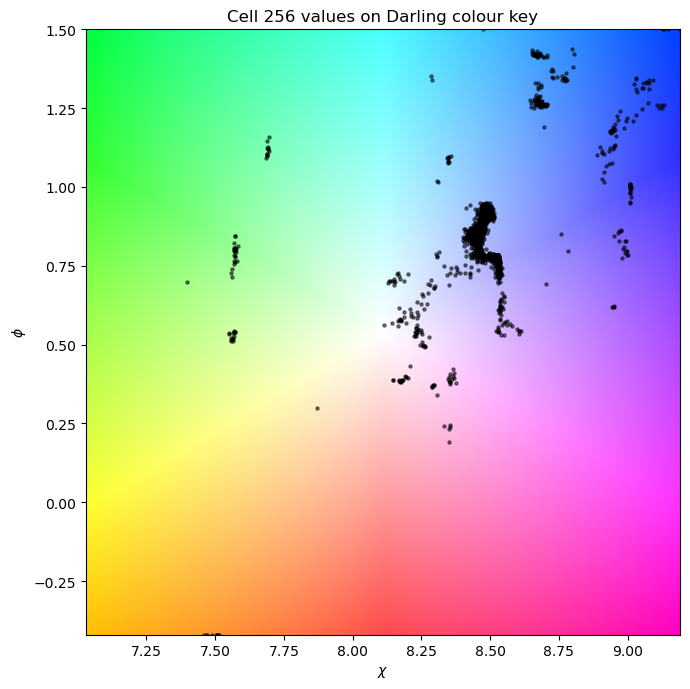

In [290]:
cell_id = cell_id  # the cell you want

# Extract only this cell
mask = labels == cell_id
zz, yy, xx = np.nonzero(mask)

print(f"cell_id = {cell_id}")
print(f"number of voxels in this cell = {len(xx)}")

if len(xx) == 0:
    raise ValueError(f"No voxels found for cell_id={cell_id}. Check that this label exists.")

# Extract only this cell's values
cell_values = registered[zz, yy, xx]

cell_phi = cell_values[..., 0]
cell_chi = cell_values[..., -1]

valid = ~np.isnan(cell_phi) & ~np.isnan(cell_chi)

print(f"valid voxels = {np.count_nonzero(valid)}")
print(f"phi range: {np.nanmin(cell_phi):.4f} to {np.nanmax(cell_phi):.4f}")
print(f"chi range: {np.nanmin(cell_chi):.4f} to {np.nanmax(cell_chi):.4f}")

chi = motors[-1]

print(chi.shape)
phi = motors[0]
print(phi.shape)

fig, ax = plt.subplots(figsize=(7, 7))

# Show Darling colour key
ax.imshow(
    colorkey,
    origin="lower",
    extent=[
        np.nanmin(chi),
        np.nanmax(chi),
        np.nanmin(phi),
        np.nanmax(phi),
    ],
    aspect="auto",
)

# Overlay only selected cell values
ax.scatter(
    cell_chi[valid],
    cell_phi[valid],
    s=5,
    c="black",
    alpha=0.5,
)

ax.set_xlabel(r"$\chi$")
ax.set_ylabel(r"$\phi$")
ax.set_title(f"Cell {cell_id} values on Darling colour key")

plt.tight_layout()
plt.show()

In [291]:
from scipy import ndimage as ndi
import numpy as np

cell_id = int(ids[order[0]])
cell_mask = labels == cell_id

# Same connectivity idea as your segmentation footprint
structure = np.zeros((3, 3, 3), dtype=bool)
structure[1, :, :] = True
structure[0, 1, 1] = True
structure[2, 1, 1] = True

cc, n_cc = ndi.label(cell_mask, structure=structure)

print("cell_id:", cell_id)
print("number of disconnected components:", n_cc)

component_sizes = np.bincount(cc.ravel())[1:]
print("component sizes:", component_sizes)

cell_id: 1
number of disconnected components: 1
component sizes: [8485]


In [292]:
out = base / "disell_3d_output"
out.mkdir(exist_ok=True)

np.save(out / "labels_cc.npy", labels)
np.save(out / "rgb_volume.npy", rgb_volume)

print("saved arrays to:", out)

saved arrays to: /home/adam/Documents/Data/4dcells/111_june/111_cells_2_6-2pct_mosalayers_2x/disell_3d_output


In [293]:
labels_to_export = labels

# Export only segmented voxels
mask_export = labels_to_export > 0

zz, yy, xx = np.nonzero(mask_export)

# Physical spacing. Replace these with real values if you know them.
dx = 1.0
dy = 1.0
dz = 1.0

points = np.column_stack([
    xx * dx,
    yy * dy,
    zz * dz,
]).astype(np.float32)

colors = rgb_volume[mask_export]
colors_uint8 = (np.clip(colors, 0, 1) * 255).astype(np.uint8)

label_values = labels_to_export[mask_export].astype(np.int32)

cloud = pv.PolyData(points)
cloud["RGB"] = colors_uint8
cloud["label"] = label_values

vtp_path = out / "segmentation_rgb_pointcloud.vtp"
cloud.save(vtp_path)

print("saved:", vtp_path)
print("points:", points.shape[0])

saved: /home/adam/Documents/Data/4dcells/111_june/111_cells_2_6-2pct_mosalayers_2x/disell_3d_output/segmentation_rgb_pointcloud.vtp
points: 4972153


/tmp/ipykernel_176548/3073497280.py:17: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


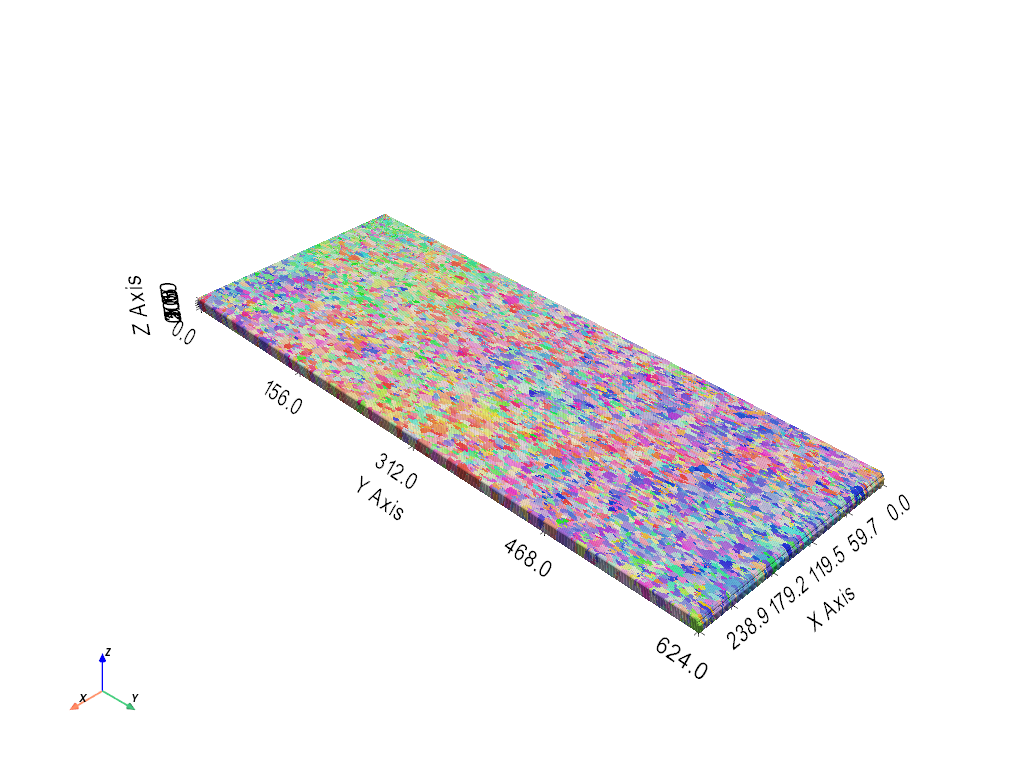

In [294]:

cloud_scaled = cloud.copy()

scale = np.array([0.33, 1, 1.0])  # x = 400 nm = 0.4 µm, y = 1 µm, z = 1 µm

cloud_scaled.points = cloud_scaled.points * scale

plotter = pv.Plotter()
plotter.add_points(
    cloud_scaled,
    scalars="RGB",
    rgb=True,
    point_size=4,
    render_points_as_spheres=True,
)
plotter.add_axes()
plotter.show_grid()
plotter.show()

using neighbour offsets: [(0, -1, -1), (0, -1, 0), (0, -1, 1), (0, 0, -1), (-1, 0, 0)]
number of cells: 9723
feature channels: 2
neighbour pairs: 47016
valid neighbour-pair misorientations: 47016
mean neighbour misorientation: 0.3691611489716786
median neighbour misorientation: 0.34354936897989974
std neighbour misorientation: 0.20702673063865662

Per-cell neighbour misorientation:
cells with neighbours: 9723
mean of per-cell mean neighbour misorientation: 0.3693839362296351
median of per-cell mean neighbour misorientation: 0.3504069715866455


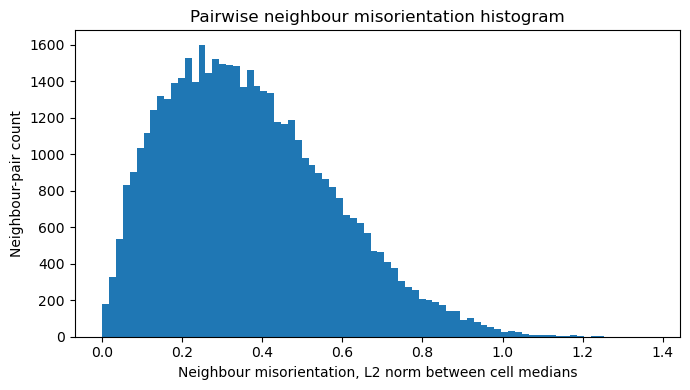

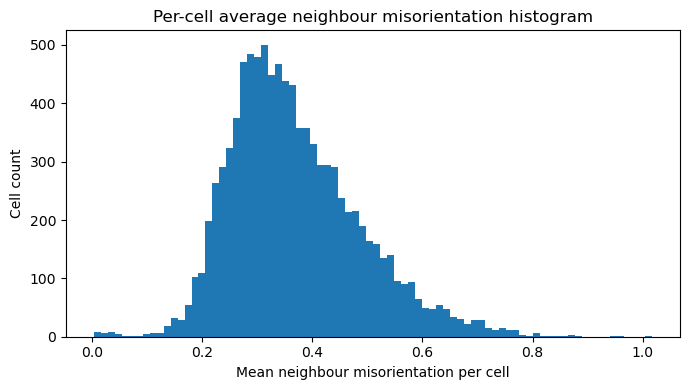

,label_a,label_b,misorientation,size_a,size_b
0,1,17,0.266130,8485,4844
1,1,642,0.570696,8485,1303
2,1,683,0.058907,8485,1323
3,1,745,0.059914,8485,1550
4,1,843,0.271724,8485,1028


,label,n_neighbours,mean_neighbour_misorientation,median_neighbour_misorientation,std_neighbour_misorientation,cell_size
0,1,38,0.289194,0.273729,0.129706,8485
1,2,27,0.508905,0.512833,0.189025,6317
2,3,24,0.317612,0.322137,0.105828,6358
3,4,30,0.326192,0.319657,0.129082,5875
4,5,27,0.352331,0.347577,0.155683,5205


In [295]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage as ndi


# ---------------------------------------------------------------------
# Inputs expected:
#   labels     : final 3D labelled segmentation, shape (Z, Y, X)
#   seg_input  : DFXM property volume, shape (Z, Y, X, C)
#   mask_bool  : valid data mask, shape (Z, Y, X)
#
# If needed:
# labels = labels_split
# ---------------------------------------------------------------------

labels = np.asarray(labels, dtype=np.int32)
features = np.asarray(seg_input, dtype=float)
mask_bool = np.asarray(mask_bool, dtype=bool)

assert labels.ndim == 3
assert features.ndim == 4
assert labels.shape == features.shape[:3]
assert labels.shape == mask_bool.shape


# ---------------------------------------------------------------------
# Connectivity definition
# Same logic as before:
#   - full 8-connectivity inside each z layer
#   - direct z-neighbour connection between adjacent layers
#
# This avoids treating diagonal inter-layer contacts as neighbours.
# ---------------------------------------------------------------------

offsets = []

# in-plane 8-connectivity
for dy in [-1, 0, 1]:
    for dx in [-1, 0, 1]:
        if dy == 0 and dx == 0:
            continue
        offsets.append((0, dy, dx))

# direct z-connectivity
offsets.append((-1, 0, 0))
offsets.append((1, 0, 0))

# Keep only one direction from each opposite pair to avoid duplicate work
unique_offsets = []
seen = set()
for dz, dy, dx in offsets:
    a = (dz, dy, dx)
    b = (-dz, -dy, -dx)
    if b in seen:
        continue
    seen.add(a)
    unique_offsets.append(a)

print("using neighbour offsets:", unique_offsets)


# ---------------------------------------------------------------------
# Compute median feature vector per label
# ---------------------------------------------------------------------

label_ids = np.unique(labels[(labels > 0) & mask_bool])
n_labels = int(label_ids.max())

cell_medians = np.full((n_labels + 1, features.shape[-1]), np.nan, dtype=float)
cell_sizes = np.zeros(n_labels + 1, dtype=np.int64)

for lab in label_ids:
    region = (labels == lab) & mask_bool
    vals = features[region]

    # Remove voxels with any non-finite channel
    finite = np.all(np.isfinite(vals), axis=1)
    vals = vals[finite]

    cell_sizes[lab] = vals.shape[0]

    if vals.shape[0] > 0:
        cell_medians[lab] = np.nanmedian(vals, axis=0)

print("number of cells:", len(label_ids))
print("feature channels:", features.shape[-1])


# ---------------------------------------------------------------------
# Find neighbouring label pairs from shifted label comparisons
# ---------------------------------------------------------------------

pairs = set()

Z, Y, X = labels.shape

for dz, dy, dx in unique_offsets:
    z0a = max(0, dz)
    z1a = Z + min(0, dz)
    y0a = max(0, dy)
    y1a = Y + min(0, dy)
    x0a = max(0, dx)
    x1a = X + min(0, dx)

    z0b = max(0, -dz)
    z1b = Z + min(0, -dz)
    y0b = max(0, -dy)
    y1b = Y + min(0, -dy)
    x0b = max(0, -dx)
    x1b = X + min(0, -dx)

    a = labels[z0a:z1a, y0a:y1a, x0a:x1a]
    b = labels[z0b:z1b, y0b:y1b, x0b:x1b]

    ma = mask_bool[z0a:z1a, y0a:y1a, x0a:x1a]
    mb = mask_bool[z0b:z1b, y0b:y1b, x0b:x1b]

    contact = (a > 0) & (b > 0) & (a != b) & ma & mb

    if not np.any(contact):
        continue

    aa = a[contact].astype(np.int64)
    bb = b[contact].astype(np.int64)

    lo = np.minimum(aa, bb)
    hi = np.maximum(aa, bb)

    for p in zip(lo, hi):
        pairs.add(p)

pairs = np.array(sorted(pairs), dtype=np.int64)

print("neighbour pairs:", len(pairs))


# ---------------------------------------------------------------------
# Compute neighbour misorientation
# Here: L2 norm between median feature vectors.
# ---------------------------------------------------------------------

rows = []

for lab_a, lab_b in pairs:
    fa = cell_medians[lab_a]
    fb = cell_medians[lab_b]

    if not (np.all(np.isfinite(fa)) and np.all(np.isfinite(fb))):
        continue

    dvec = fb - fa
    mis = np.linalg.norm(dvec)

    rows.append(
        {
            "label_a": int(lab_a),
            "label_b": int(lab_b),
            "misorientation": float(mis),
            "size_a": int(cell_sizes[lab_a]),
            "size_b": int(cell_sizes[lab_b]),
        }
    )

neighbour_df = pd.DataFrame(rows)

print("valid neighbour-pair misorientations:", len(neighbour_df))
print("mean neighbour misorientation:", neighbour_df["misorientation"].mean())
print("median neighbour misorientation:", neighbour_df["misorientation"].median())
print("std neighbour misorientation:", neighbour_df["misorientation"].std())


# ---------------------------------------------------------------------
# Average neighbour misorientation per cell
# ---------------------------------------------------------------------

per_cell_rows = []

for lab in label_ids:
    lab = int(lab)

    m = (neighbour_df["label_a"] == lab) | (neighbour_df["label_b"] == lab)
    vals = neighbour_df.loc[m, "misorientation"].to_numpy()

    if vals.size == 0:
        continue

    per_cell_rows.append(
        {
            "label": lab,
            "n_neighbours": int(vals.size),
            "mean_neighbour_misorientation": float(np.mean(vals)),
            "median_neighbour_misorientation": float(np.median(vals)),
            "std_neighbour_misorientation": float(np.std(vals)),
            "cell_size": int(cell_sizes[lab]),
        }
    )

cell_neighbour_df = pd.DataFrame(per_cell_rows)

print("\nPer-cell neighbour misorientation:")
print("cells with neighbours:", len(cell_neighbour_df))
print(
    "mean of per-cell mean neighbour misorientation:",
    cell_neighbour_df["mean_neighbour_misorientation"].mean(),
)
print(
    "median of per-cell mean neighbour misorientation:",
    cell_neighbour_df["mean_neighbour_misorientation"].median(),
)


# ---------------------------------------------------------------------
# Histograms
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(neighbour_df["misorientation"], bins=80)
ax.set_xlabel("Neighbour misorientation, L2 norm between cell medians")
ax.set_ylabel("Neighbour-pair count")
ax.set_title("Pairwise neighbour misorientation histogram")
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(cell_neighbour_df["mean_neighbour_misorientation"], bins=80)
ax.set_xlabel("Mean neighbour misorientation per cell")
ax.set_ylabel("Cell count")
ax.set_title("Per-cell average neighbour misorientation histogram")
plt.tight_layout()
plt.show()


# Optional: quick preview tables
display(neighbour_df.head())
display(cell_neighbour_df.head())

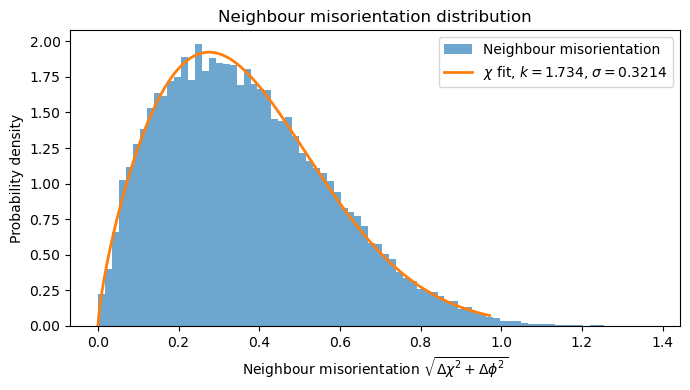

Chi k / df:      1.7339
Chi sigma:       0.3214
Chi loc:         0.0000
empirical mean:  0.3692
Chi mean:        0.3687
empirical std:   0.2070
Chi std:         0.2079
empirical median:0.3435
Chi median:      0.3417


In [296]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

mis = neighbour_df["misorientation"].to_numpy()
mis = mis[np.isfinite(mis)]
mis = mis[mis > 0]

# ---------------------------------------------------------------------
# Chi-distribution fit
# scipy.stats.chi has parameters:
#   df    = k, degrees of freedom
#   loc   = location, fixed to 0 here
#   scale = sigma
#
# Fix loc=0 because misorientation is non-negative and should start at zero.
# ---------------------------------------------------------------------

k_hat, loc_hat, sigma_hat = stats.chi.fit(mis, floc=0)

x = np.linspace(0, np.percentile(mis, 99.5), 500)
pdf_chi = stats.chi.pdf(x, df=k_hat, loc=0, scale=sigma_hat)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    mis,
    bins=80,
    density=True,
    alpha=0.65,
    label="Neighbour misorientation",
)

ax.plot(
    x,
    pdf_chi,
    linewidth=2,
    label=fr"$\chi$ fit, $k={k_hat:.3f}$, $\sigma={sigma_hat:.4f}$",
)

ax.set_xlabel(r"Neighbour misorientation $\sqrt{\Delta\chi^2 + \Delta\phi^2}$")
ax.set_ylabel("Probability density")
ax.set_title("Neighbour misorientation distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Chi k / df:      {k_hat:.4f}")
print(f"Chi sigma:       {sigma_hat:.4f}")
print(f"Chi loc:         {loc_hat:.4f}")
print(f"empirical mean:  {np.mean(mis):.4f}")
print(f"Chi mean:        {stats.chi.mean(df=k_hat, loc=0, scale=sigma_hat):.4f}")
print(f"empirical std:   {np.std(mis):.4f}")
print(f"Chi std:         {stats.chi.std(df=k_hat, loc=0, scale=sigma_hat):.4f}")
print(f"empirical median:{np.median(mis):.4f}")
print(f"Chi median:      {stats.chi.median(df=k_hat, loc=0, scale=sigma_hat):.4f}")

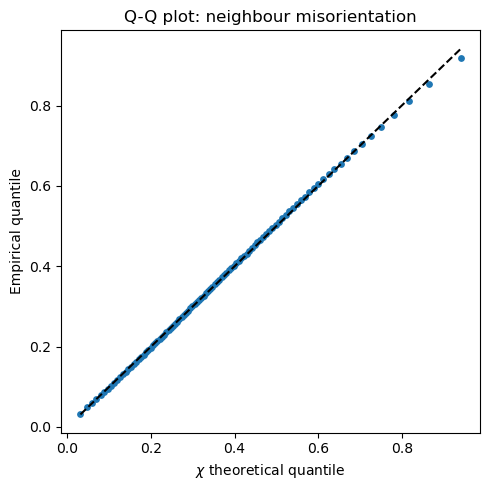

In [297]:
qs = np.linspace(0.01, 0.99, 99)

emp_q = np.quantile(mis, qs)
chi_q = stats.chi.ppf(qs, df=k_hat, loc=0, scale=sigma_hat)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(chi_q, emp_q, s=15)
ax.plot(
    [chi_q.min(), chi_q.max()],
    [chi_q.min(), chi_q.max()],
    "k--",
)
ax.set_xlabel(r"$\chi$ theoretical quantile")
ax.set_ylabel("Empirical quantile")
ax.set_title("Q-Q plot: neighbour misorientation")
plt.tight_layout()
plt.show()

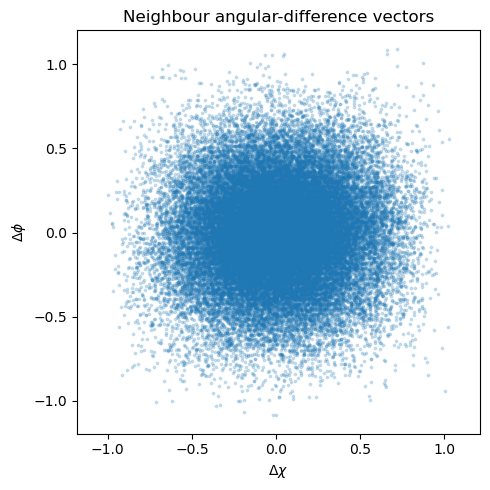

mean Δχ: 0.00912030127894515
mean Δφ: -0.004284784441167686
std Δχ: 0.30962758830116266
std Δφ: 0.28838919326616774
corr Δχ, Δφ: 0.03612682885701868


In [298]:
dchi = []
dphi = []

for _, row in neighbour_df.iterrows():
    a = int(row["label_a"])
    b = int(row["label_b"])

    fa = cell_medians[a]
    fb = cell_medians[b]

    dchi.append(fb[0] - fa[0])
    dphi.append(fb[1] - fa[1])

dchi = np.asarray(dchi)
dphi = np.asarray(dphi)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(dchi, dphi, s=3, alpha=0.2)
ax.set_xlabel(r"$\Delta\chi$")
ax.set_ylabel(r"$\Delta\phi$")
ax.set_title("Neighbour angular-difference vectors")
ax.axis("equal")
plt.tight_layout()
plt.show()

print("mean Δχ:", np.mean(dchi))
print("mean Δφ:", np.mean(dphi))
print("std Δχ:", np.std(dchi))
print("std Δφ:", np.std(dphi))
print("corr Δχ, Δφ:", np.corrcoef(dchi, dphi)[0, 1])